# Práctica Ensamble Learning
### Data Science 8CC2
### Universidad Autónoma de Chihuahua
### Facultad de Ingenieria
### Ingenieria en ciencias de la computación
### Docente: Olanda Prieto Ordaz
### Fecha de entrega: Miercoles 22  de octubre del 2025
*Allan Hall Solorio 358909*

# Introducción

En esta práctica se realizo una implementación del modelo de Ensamble Learning de la base de datos de Kaggle: Lung Cancer, para predicción de cáncer de pulmon en personas.

A continuación se describen los pasos realizados:

1.   **Obtención del dataset de Kaggle**
2.   **Exploración inicial de los datos:** Análisis inicial para comprender la estructura de los datos, identificar posibles problemas (como valores faltantes o inconsistencias) y visualizar distribuciones de características clave.
3. **Partición de los datos en train y test:** División del dataset en conjuntos de entrenamiento y prueba para la evaluación del modelo.
4. **Preprocesamiento de los datos:**  Implementación de un pipeline para transformar los datos, incluyendo escalado numérico y codificación de variables categóricas.
5. **Implementación de un modelo de Ensamble con VotingClassifier**
6. **Implementación de un modelo de Ensamble con Bagging**
7. **Implementación de un modelo de Ensamble con Pasting**
8. **Implementación de un modelo de Ensamble con AdaBoost**
9. **Implementación de un modelo de Ensamble con GradientBoost**
10. **Implementación de un modelo de Ensamble con XGBoost**
11. **Evaluación del modelo final:** Evaluación del mejor modelo obtenido en el conjunto de prueba no visto para obtener métricas finales de rendimiento (Accuracy, Precision, Recall, F1-score y Matriz de Confusión).
12. **Comparación de los resultados obtenidos con todos los modelos implementados con anterioridad**
13. **Conclusion**


In [ ]:
#1º Obtención de la base de datos (Kaggle)
!pip install kaggle
!mkdir -p ~/.kaggle
!cp /content/kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download mysarahmadbhat/lung-cancer -p /content/dataset --unzip

Dataset URL: https://www.kaggle.com/datasets/mysarahmadbhat/lung-cancer
License(s): CC0-1.0
  0% 0.00/2.00k [00:00<?, ?B/s]
100% 2.00k/2.00k [00:00<00:00, 8.19MB/s]


In [ ]:
# 2º Exploración de la base de datos
import pandas as pd
df = pd.read_csv('/content/dataset/survey lung cancer.csv')
df.head()

,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN,LUNG_CANCER
0,M,69,1,2,2,1,1,2,1,2,2,2,2,2,2,YES
1,M,74,2,1,1,1,2,2,2,1,1,1,2,2,2,YES
2,F,59,1,1,1,2,1,2,1,2,1,2,2,1,2,NO
3,M,63,2,2,2,1,1,1,1,1,2,1,1,2,2,NO
4,F,63,1,2,1,1,1,1,1,2,1,2,2,1,1,NO


In [ ]:
df.describe()

,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN
count,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000
mean,62.673139,1.563107,1.569579,1.498382,1.501618,1.504854,1.673139,1.556634,1.556634,1.556634,1.579288,1.640777,1.469256,1.556634
std,8.210301,0.496806,0.495938,0.500808,0.500808,0.500787,0.469827,0.497588,0.497588,0.497588,0.494474,0.480551,0.499863,0.497588
min,21.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,57.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
50%,62.000000,2.000000,2.000000,1.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,1.000000,2.000000
75%,69.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000
max,87.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 309 entries, 0 to 308
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   GENDER                 309 non-null    object
 1   AGE                    309 non-null    int64 
 2   SMOKING                309 non-null    int64 
 3   YELLOW_FINGERS         309 non-null    int64 
 4   ANXIETY                309 non-null    int64 
 5   PEER_PRESSURE          309 non-null    int64 
 6   CHRONIC DISEASE        309 non-null    int64 
 7   FATIGUE                309 non-null    int64 
 8   ALLERGY                309 non-null    int64 
 9   WHEEZING               309 non-null    int64 
 10  ALCOHOL CONSUMING      309 non-null    int64 
 11  COUGHING               309 non-null    int64 
 12  SHORTNESS OF BREATH    309 non-null    int64 
 13  SWALLOWING DIFFICULTY  309 non-null    int64 
 14  CHEST PAIN             309 non-null    int64 
 15  LUNG_CANCER            

In [ ]:
df.isnull().sum()

,0
GENDER,0
AGE,0
SMOKING,0
YELLOW_FINGERS,0
ANXIETY,0
PEER_PRESSURE,0
CHRONIC DISEASE,0
FATIGUE,0
ALLERGY,0
WHEEZING,0


<Axes: >

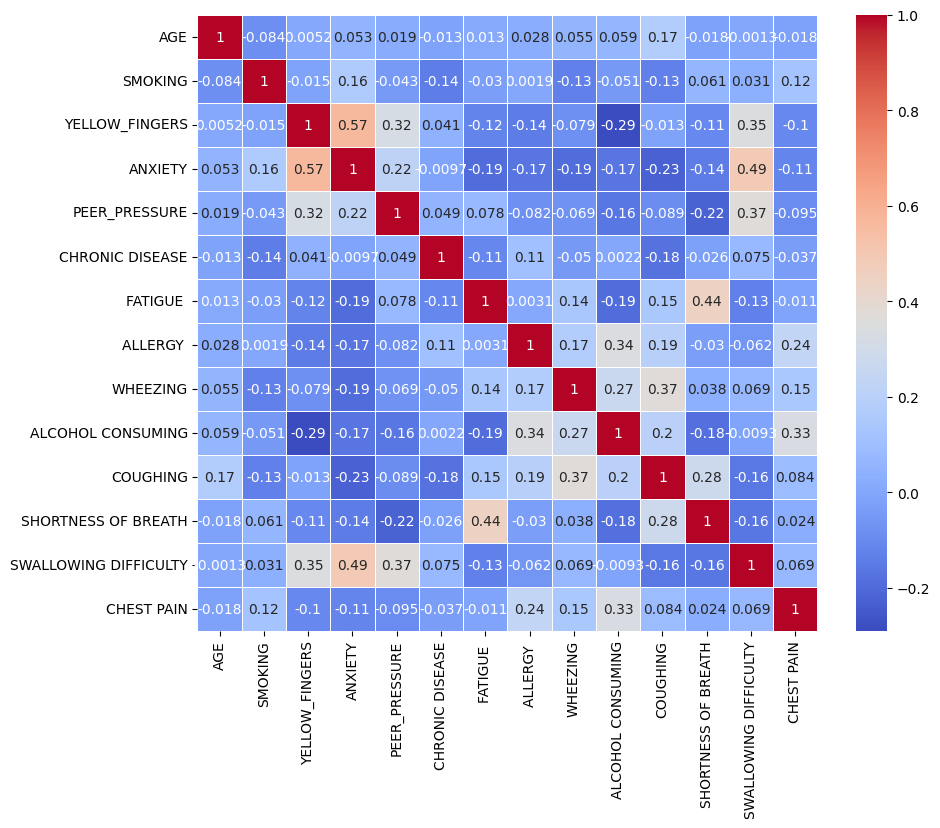

In [ ]:
# matriz de correlación
import seaborn as sns
import matplotlib.pyplot as plt

# seleccionar solo las columnas numericas para la matriz de correlacion
df_numeric = df.select_dtypes(include=['int64', 'float64'])

#calcular la matriz
correlation_matrix = df_numeric.corr()

#crear un mapa de calor
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)

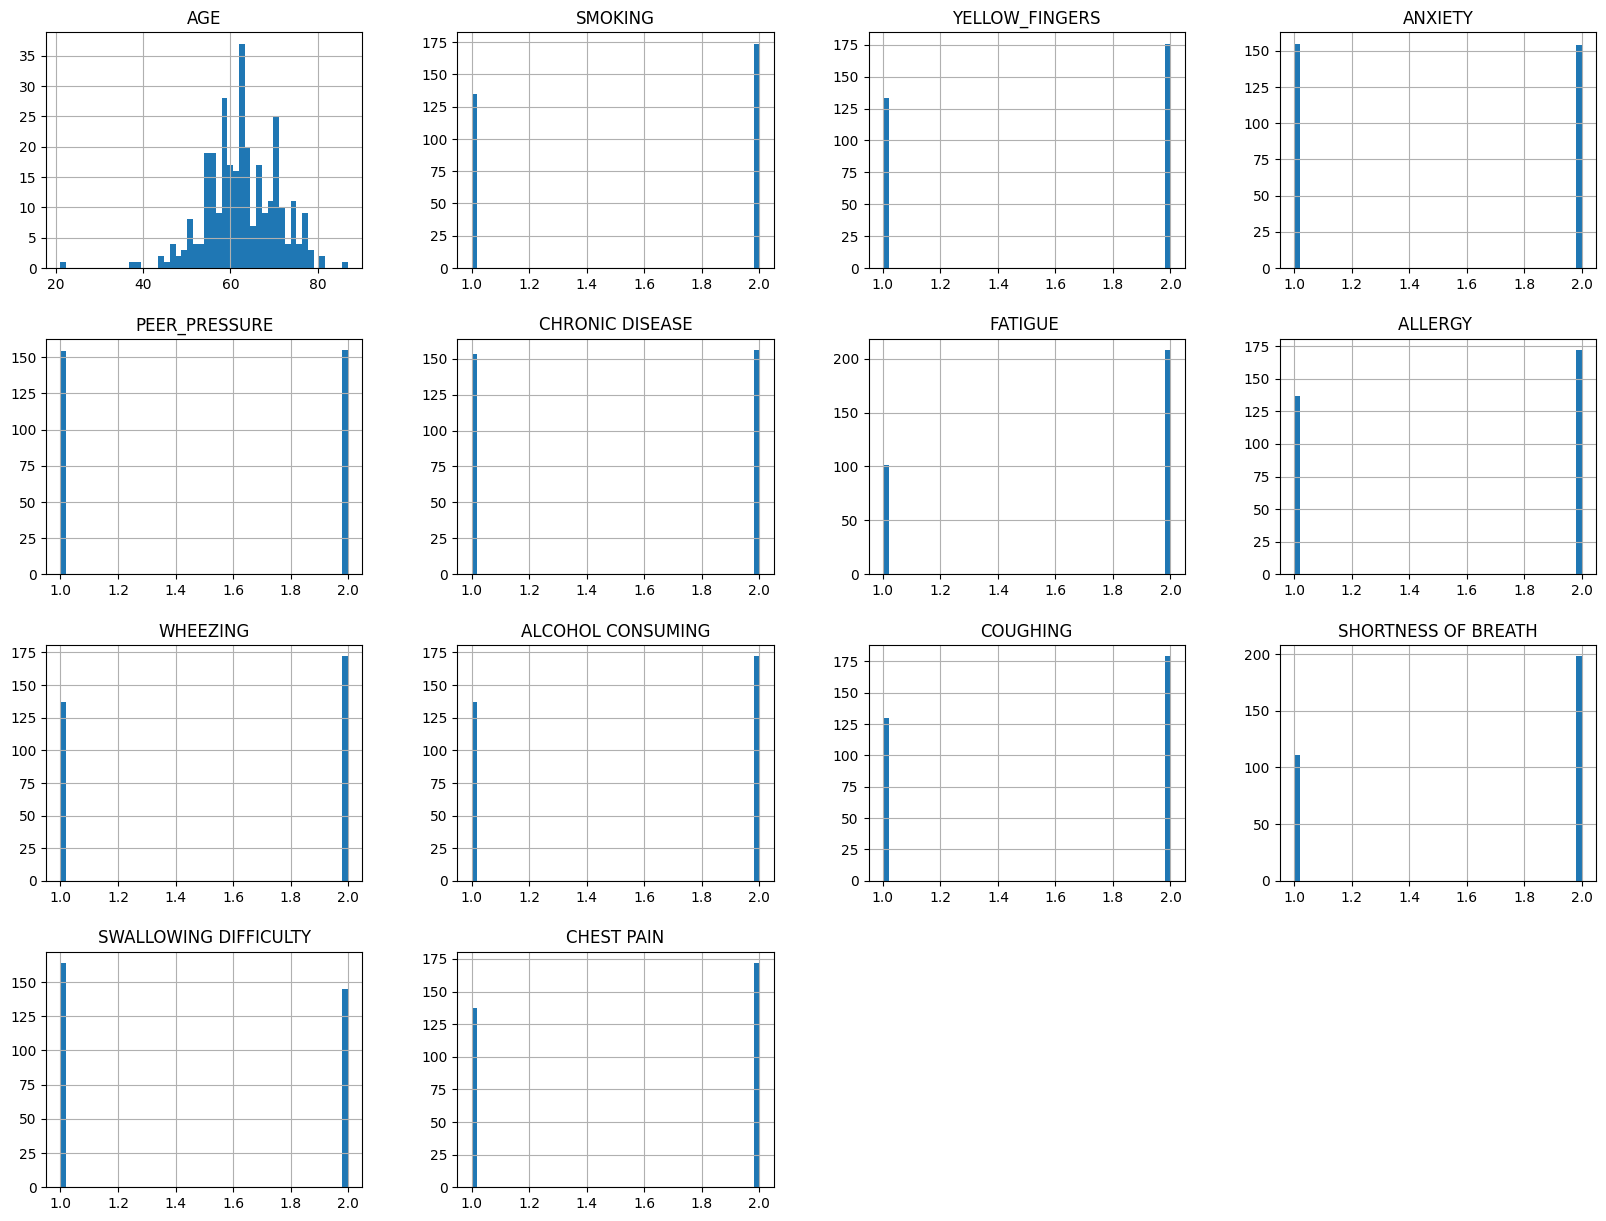

In [ ]:
# obtener graficas
df_numeric = df.select_dtypes(include=['int64', 'float64'])
df_numeric.hist(bins=50, figsize=(20, 15))
plt.show()

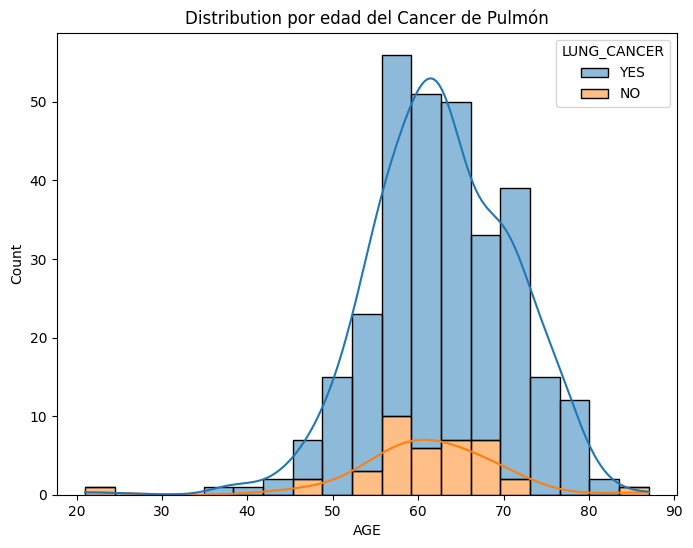

In [ ]:
# Visualizar la distribucion por edad del cancer de Pulmón
plt.figure(figsize=(8, 6))
sns.histplot(data=df, x='AGE', hue='LUNG_CANCER', multiple='stack', kde=True)
plt.title('Distribution por edad del Cancer de Pulmón')
plt.show()

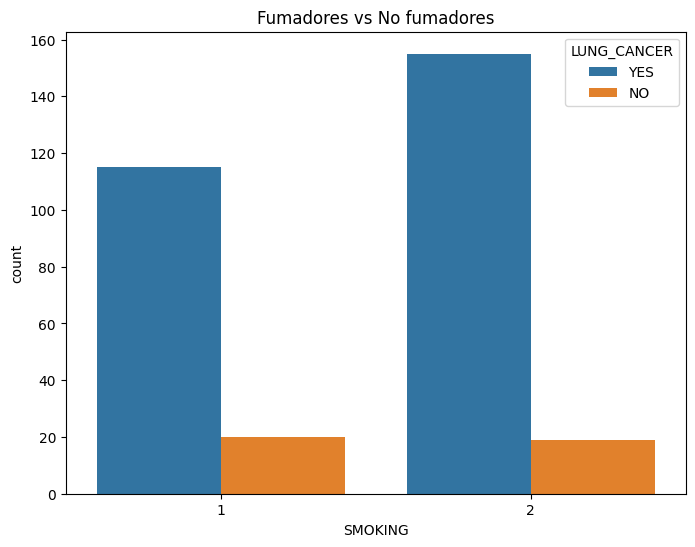

In [ ]:
# Visualizar la cantidad de fumadores y no fumadores y su relación con el cancer
# 1 = No fumador, 2 = fumador
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='SMOKING', hue='LUNG_CANCER')
plt.title('Fumadores vs No fumadores')
plt.show()

In [ ]:
# tabla cruzada para ver en porcentaje los fumadores y no fumadores
pd.crosstab(df['SMOKING'], df['LUNG_CANCER'], normalize='index')*100

LUNG_CANCER,NO,YES
SMOKING,,
1,14.814815,85.185185
2,10.919540,89.080460


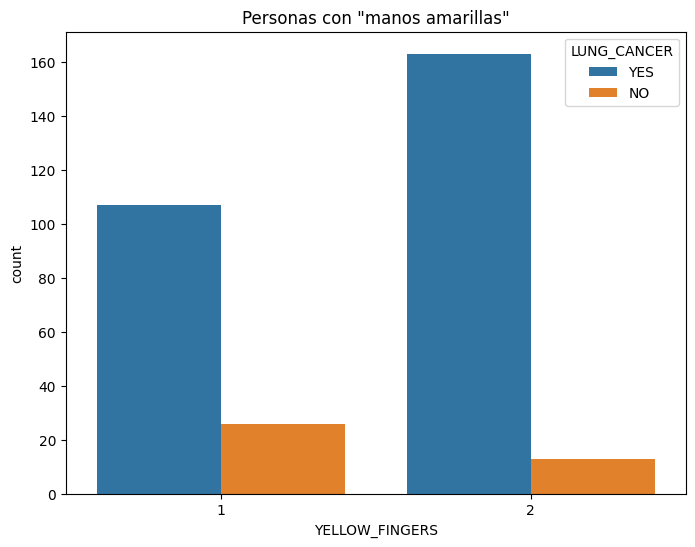

In [ ]:
# Visualizar la cantidad de personas con las manos de color amarillas (yellow_fingers) y su relacion con el cancer
# 1 = No , 2 = Si
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='YELLOW_FINGERS', hue='LUNG_CANCER')
plt.title('Personas con "manos amarillas"')
plt.show()

In [ ]:
# tabla cruzada para visualizarlo en porcentaje
pd.crosstab(df['YELLOW_FINGERS'], df['LUNG_CANCER'], normalize='index')*100

LUNG_CANCER,NO,YES
YELLOW_FINGERS,,
1,19.548872,80.451128
2,7.386364,92.613636


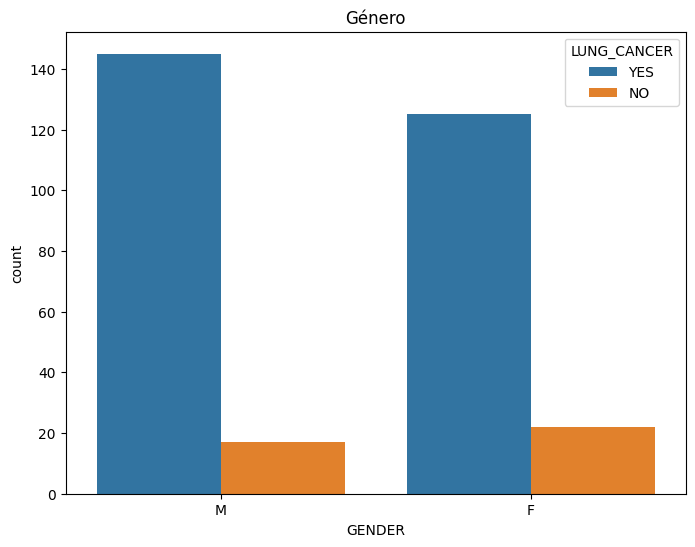

In [ ]:
# Visualizar la cantidad de personas por genero
# Gender: M(male), F(female)
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='GENDER', hue='LUNG_CANCER')
plt.title('Género')
plt.show()

In [ ]:
# tabla cruzada para visualizarlo en porcentaje
pd.crosstab(df['GENDER'], df['LUNG_CANCER'], normalize='index')*100

LUNG_CANCER,NO,YES
GENDER,,
F,14.965986,85.034014
M,10.493827,89.506173


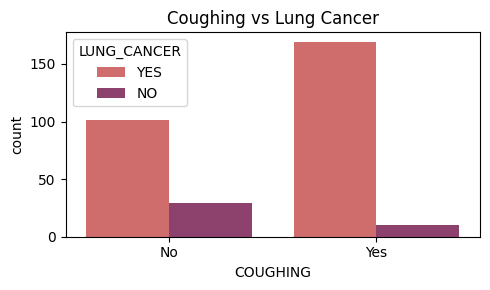

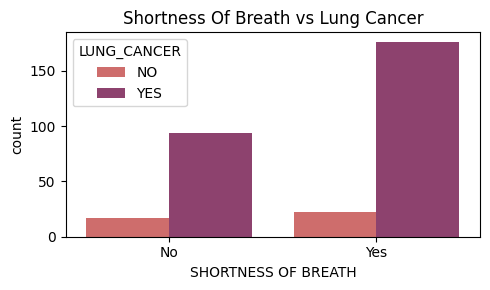

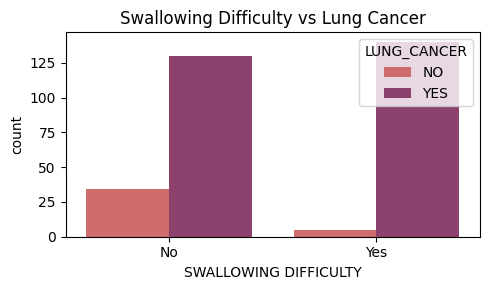

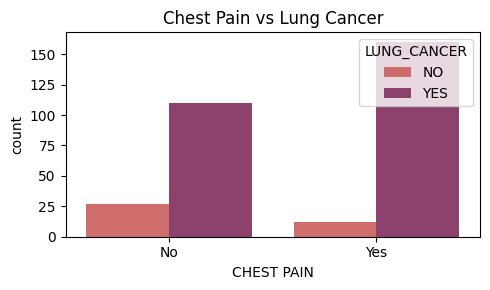

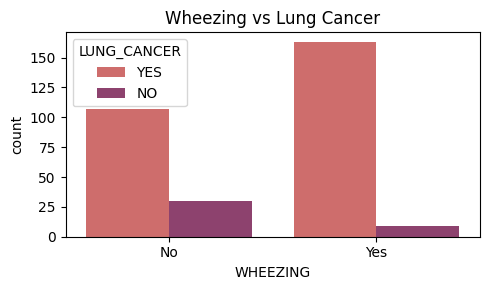

In [ ]:
symptoms = ['COUGHING', 'SHORTNESS OF BREATH', 'SWALLOWING DIFFICULTY', 'CHEST PAIN', 'WHEEZING']

for col in symptoms:
    plt.figure(figsize=(5, 3))
    sns.countplot(data=df, x=col, hue='LUNG_CANCER', palette='flare')
    plt.title(f"{col.replace('_', ' ').title()} vs Lung Cancer")
    plt.xticks([0, 1], ['No', 'Yes'])
    plt.tight_layout()
    plt.show()

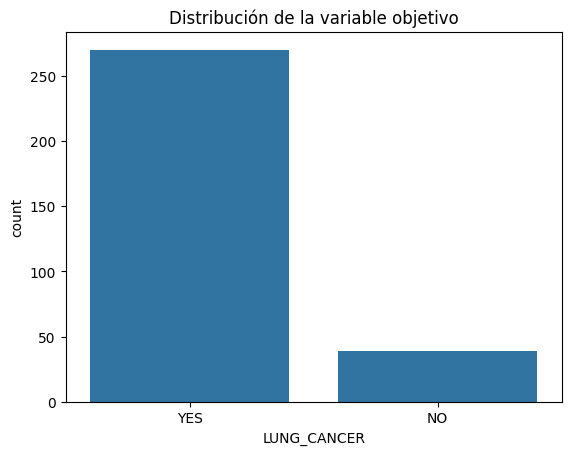

In [ ]:
# Distribución de la variable objetivo (lung_cancer)
sns.countplot(x="LUNG_CANCER", data=df)
plt.title("Distribución de la variable objetivo")
plt.show()

In [ ]:
# sacar dichos datos del gráfico en porcentaje, para apreciar mejor el desbalanceo
print(df['LUNG_CANCER'].value_counts(normalize=True) * 100)

LUNG_CANCER
YES    87.378641
NO     12.621359
Name: proportion, dtype: float64


El propósito de este último gráfico fue para checar si nuestra variable objetivo (lung_cancer) esta desbalanceada. Ya que, para el siguiente paso, que es hacer la particion de los datos (train/test) es escencial saber si es necesario la partición estratificada.

Casi siempre con problemas de clasificación es casi obligatorio usar la estratificación a la hora de hacer la partición.

In [ ]:
# 3º Realizar la partición estratificada
from sklearn.model_selection import train_test_split

# Separar las features (X) y nuestro target (y)
X = df.drop('LUNG_CANCER', axis=1)
y = df['LUNG_CANCER']

# Realizar la partición
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
# 4. Validar que las particiones de Train/Test tengan la misma distribución en ambas particiones
print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)
print("\nDistribucion de LUNG_CANCER en train:")
print(y_train.value_counts(normalize=True) * 100)
print("\nDistribucion de LUNG_CANCER in test:")
print(y_test.value_counts(normalize=True) * 100)

Training set shape: (247, 15)
Testing set shape: (62, 15)

Distribucion de LUNG_CANCER en train:
LUNG_CANCER
YES    87.449393
NO     12.550607
Name: proportion, dtype: float64

Distribucion de LUNG_CANCER in test:
LUNG_CANCER
YES    87.096774
NO     12.903226
Name: proportion, dtype: float64


In [ ]:
# 5º Implementar la transformación de los datos por medio de un pipeline.
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.pipeline import Pipeline

# Identificar columnas numéricas y categóricas
# Excluyendo la variable objetivo 'Lung_cancer' porque ya está separada
numerical_features = ['AGE']
categorical_features = ['GENDER']

other_numerical_features = ['SMOKING', 'YELLOW_FINGERS', 'ANXIETY', 'PEER_PRESSURE',
                           'CHRONIC DISEASE', 'FATIGUE ', 'ALLERGY ', 'WHEEZING',
                           'ALCOHOL CONSUMING', 'COUGHING', 'SHORTNESS OF BREATH',
                           'SWALLOWING DIFFICULTY', 'CHEST PAIN']

# Crear pipelines de preprocesamiento para características numéricas y categóricas
numerical_pipeline = Pipeline([

    ('scaler', MinMaxScaler())
])

categorical_pipeline = Pipeline([
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Combinar los pasos de preprocesamiento utilizando ColumnTransformer
preprocessor = ColumnTransformer([
    ('num', numerical_pipeline, numerical_features + other_numerical_features),
    ('cat', categorical_pipeline, categorical_features)
])

# Ajustar y transformar los datos de train
X_train_processed = preprocessor.fit_transform(X_train)

# Forma de los datos de train
print("Shape of processed training data:", X_train_processed.shape)

Shape of processed training data: (247, 16)


El objetivo de este código es preparar los datos de entrenamiento (X_train) para ser utilizados por el modelo de Machine Learning. Los modelos a menudo requieren que los datos estén en un formato numérico y en una escala similar para funcionar correctamente y de manera eficiente.

1.   Importación de Librerias:
    
  * ColumnTransformer: Esta herramienta de scikit-learn te permite aplicar diferentes transformaciones a diferentes columnas de tu dataset simultáneamente. Es muy útil cuando tienes columnas de diferentes tipos (numéricas, categóricas) que requieren preprocesamiento distinto.
  * MinMaxScaler: Este es un escalador que transforma las características numéricas escalándolas a un rango dado, generalmente entre 0 y 1. Esto ayuda a que las características numéricas estén en una escala comparable, lo cual es importante para muchos algoritmos de Machine Learning (como SGDClassifier).
  * OneHotEncoder: Este codificador se utiliza para convertir variables categóricas nominales (como 'GENDER', que tiene categorías 'M' y 'F') en un formato numérico que los modelos puedan entender. Crea una nueva columna binaria por cada categoría única en la característica original.
  * Pipeline: La clase Pipeline te permite encadenar múltiples pasos de preprocesamiento y un estimador en un solo objeto. Esto simplifica el código y asegura que los pasos de preprocesamiento se apliquen de manera consistente tanto a los datos de entrenamiento como a los de prueba.
2.   Identificar Columnas:
  * Se definen listas para separar los nombres de las columnas numéricas (numerical_features) y categóricas (categorical_features) que serán preprocesadas. La variable objetivo ('LUNG_CANCER') no se incluye aquí porque se separo previamente.
  * other_numerical_features incluye las columnas que, aunque representadas como 1 y 2, se tratan como numéricas para aplicarles el escalado.
  3. Crear Pipelines para Tipos de Datos:
  * numerical_pipeline: Se crea un Pipeline específico para las características numéricas. En este caso, solo incluye el paso de escalado con MinMaxScaler(). Si hubiera valores nulos en las columnas numéricas, aquí se añadiría un paso de imputación antes del escalado.
  * categorical_pipeline: Se crea un Pipeline para las características categóricas. Aquí solo se incluye el paso de OneHotEncoder(). handle_unknown='ignore' es útil para manejar posibles categorías nuevas en el conjunto de prueba que no se vieron en el entrenamiento, asignándoles ceros en todas las columnas codificadas.
  4. Combinar Pasos con ColumnTransformer:
* Se crea un objeto preprocessor usando ColumnTransformer.
* Se le pasan tuplas que especifican:
    * Un nombre para el transformador ('num', 'cat').
    * El pipeline a aplicar ( numerical_pipeline, categorical_pipeline).
    * La lista de columnas a las que se aplicará ese pipeline (numerical_features + other_numerical_features para el pipeline numérico, categorical_features para el pipeline categórico).
* ColumnTransformer se encargará de aplicar cada pipeline a las columnas correctas y luego concatenar los resultados.
5. Ajustar y Transformar los Datos de Entrenamiento:
  * preprocessor.fit_transform(X_train): Este es el paso donde el pipeline de preprocesamiento "aprende" de los datos de entrenamiento (fit) y luego aplica las transformaciones (transform).
    * fit: Calcula los parámetros necesarios para las transformaciones (por ejemplo, el mínimo y máximo para MinMaxScaler, las categorías únicas para OneHotEncoder) utilizando solo los datos de X_train.
    * transform: Aplica estas transformaciones a X_train utilizando los parámetros aprendidos en el paso fit.
  * El resultado es X_train_processed, que es un array NumPy con todos los datos de entrenamiento preprocesados y listos para ser utilizados por el modelo.

  6. Verificar la Forma de los Datos Procesados:
    * print("Shape of processed training data:", X_train_processed.shape): Imprime las dimensiones del array NumPy resultante. La cantidad de filas debe ser la misma que en X_train, y la cantidad de columnas será la original menos la columna categórica, más las nuevas columnas binarias creadas por OneHotEncoder para cada categoría única de 'GENDER'.


En resumen, este pipeline automatiza y organiza los pasos necesarios para transformar los datos brutos de entrenamiento en un formato adecuado para el entrenamiento del modelo de regresión logística, asegurando que el escalado y la codificación se apliquen correctamente a las columnas apropiadas.

In [ ]:
# Mostrar el dataframe despues de la transformacion
df_train_processed = pd.DataFrame(X_train_processed)
df_train_processed.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
0,0.469388,1.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,1.0,0.0
1,0.530612,1.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0
2,0.714286,1.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
3,0.489796,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0
4,0.265306,0.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,0.0,1.0


# 6) Implementación de 6 diferentes modelos de Ensamble

## A) Implementación de un modelo de Ensamble usando VotingClassifier - Hard Voting

Para este modelo se eligieron como clasificadores base: Regresion Logistica, Arboles de desicion y Random Forest, por varias razones

1.   **Diversidad de modelos:** Estos 3 modelos representan diferentes tipos de algoritmos de Machine Learning con distintas formas de "aprender" de los datos y tomar decisiones:
      - Regresion Logistica: Es un modelo lineal que aprende una frontera de decisión lineal. Es relativamente simple y rápido.
      - Árbol de decision: Es un modelo no lineal que toma decisiones secuenciales basadas en divisiones de características. Puede capturar interacciones no lineales, pero un solo árbol puede ser propenso al sobreajuste.
      - Random Forest: Es un método de ensamble (basado en bagging) que combina múltiples árboles de decisión. Reduce la varianza del árbol de decisión individual y suele ser robusto y de buen rendimiento.
   
   Al combinar modelos con diferentes sesgos y varianzas, el VotingClassifier puede beneficiarse de sus fortalezas individuales y, en teoría, mitigar sus debilidades. La diversidad en los clasificadores base es clave para que un ensamble por votación sea efectivo.

2.   **Rendimiento Conocido:** Estos modelos son algoritmos fundamentales y ampliamente utilizados en Machine Learning con un rendimiento generalmente bueno en una variedad de problemas de clasificación. Son buenos puntos de partida para un ensamble.

3. **Complementariedad:** La Regresión Logística (lineal) puede capturar relaciones simples, mientras que los árboles de decisión y Random Forest (no lineales) pueden modelar patrones más complejos. La combinación de un modelo lineal con modelos basados en árboles puede ser complementaria.
4. **Facilidad de Implementación y Comprensión:** Son modelos relativamente fáciles de implementar y entender en comparación con otros algoritmos más complejos, lo que facilita la construcción y depuración del ensamble.

En resumen, la combinación de Regresión Logística, Árbol de Decisión y Random Forest busca aprovechar la diversidad de sus enfoques para la clasificación, esperando que el ensamble por votación logre una predicción más robusta y precisa que cualquiera de los modelos por sí solo.



Evaluación de VotingClassifier (Hard Voting):
Accuracy: 0.9194
Precision: 0.9623
Recall: 0.9444
F1-score: 0.9533


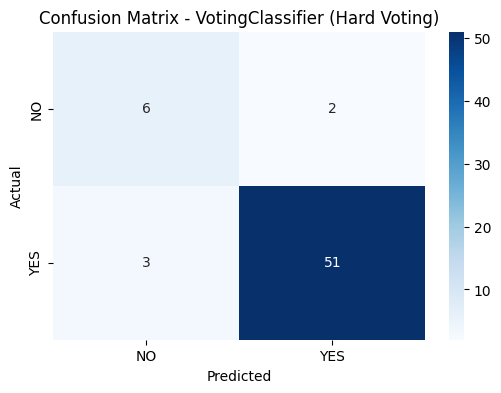

In [ ]:
from sklearn.ensemble import VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Implementación de VotingClassifier - Hard Voting

# Definir los clasificadores base
log_reg = LogisticRegression(random_state=42)
tree_clf = DecisionTreeClassifier(random_state=42)
rnd_clf = RandomForestClassifier(random_state=42)

# Crear el VotingClassifier con Hard Voting
# Se usa 'hard' por defecto, pero se especifica para claridad
voting_clf_hard = VotingClassifier(
    estimators=[('lr', log_reg), ('dt', tree_clf), ('rf', rnd_clf)],
    voting='hard'
)

# Entrenar el VotingClassifier en los datos preprocesados de entrenamiento
# Es importante usar los datos preprocesados (escalados y codificados)
voting_clf_hard.fit(X_train_processed, y_train)

# Preprocesar los datos de prueba
X_test_processed = preprocessor.transform(X_test)

# Realizar predicciones en el conjunto de prueba
y_pred_hard = voting_clf_hard.predict(X_test_processed)

# Evaluar el modelo
print("Evaluación de VotingClassifier (Hard Voting):")
print(f"Accuracy: {accuracy_score(y_test, y_pred_hard):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_hard, pos_label='YES'):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_hard, pos_label='YES'):.4f}")
print(f"F1-score: {f1_score(y_test, y_pred_hard, pos_label='YES'):.4f}")

# Matriz de confusión
cm_hard = confusion_matrix(y_test, y_pred_hard, labels=['NO', 'YES'])
plt.figure(figsize=(6, 4))
sns.heatmap(cm_hard, annot=True, fmt='d', cmap='Blues', xticklabels=['NO', 'YES'], yticklabels=['NO', 'YES'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - VotingClassifier (Hard Voting)')
plt.show()

## Interpretación de los resultados

*   **Accuracy: 0.9194**

Esto significa que el modelo predijo correctamente el 91.94% de los casos en el conjunto de prueba. Es una métrica general del rendimiento del modelo. Un accuracy alto es generalmente bueno, pero en problemas con clases desbalanceadas (como este, donde hay muchos más casos 'YES' que 'NO'), no siempre cuenta la historia completa.
*   **Precision: 0.9623**

La precisión mide la proporción de predicciones positivas (casos de cáncer de pulmón predichos como 'YES') que fueron realmente correctas. Una precisión de 0.9623 significa que, de todos los casos que el modelo predijo como 'YES', el 96.23% realmente tenían cáncer de pulmón. Una alta precisión indica que el modelo tiene pocos falsos positivos (predice 'YES' cuando en realidad es 'NO'). Esto es importante si quieres minimizar las alarmas falsas.

* **Recall: 0.9444**

El recall (también conocido como sensibilidad) mide la proporción de casos positivos reales (personas que realmente tienen cáncer de pulmón) que el modelo identificó correctamente. Un recall de 0.9444 significa que el modelo fue capaz de identificar correctamente el 94.44% de todas las personas que realmente tenían cáncer de pulmón en el conjunto de prueba. Un recall alto indica que el modelo tiene pocos falsos negativos (predice 'NO' cuando en realidad es 'YES'). Esto es crucial en problemas médicos donde no quieres pasar por alto casos positivos.

* **F1-score: 0.9533**

El F1-score es la media armónica de la precisión y el recall. Proporciona un equilibrio entre ambas métricas. Un F1-score alto sugiere que el modelo tiene un buen equilibrio entre identificar correctamente los casos positivos y evitar falsos positivos. Un F1-score de 0.9533 es bastante alto, lo que indica un buen rendimiento general del modelo, especialmente útil en datasets desbalanceados.

En resumen los resultados muestran que el VotingClassifier con Hard Voting tuvo un rendimiento muy bueno en la predicción de cáncer de pulmón en este dataset.

* El Accuracy es alto, indicando que el modelo es generalmente correcto.
*  La Precision es excelente, lo que significa que cuando el modelo predice cáncer, es muy probable que sea cierto. Esto minimiza las preocupaciones por falsos positivos.
  * El Recall también es muy bueno, lo que indica que el modelo es efectivo para detectar la mayoría de los casos reales de cáncer de pulmón, minimizando los falsos negativos, lo cual es crítico en una aplicación médica.
  * El F1-score confirma que hay un buen equilibrio entre precisión y recall.


  Considerando la naturaleza del problema (detección de cáncer), un alto recall es particularmente importante para no pasar por alto casos. La alta precisión también es valiosa para reducir tratamientos o pruebas innecesarias. Los resultados obtenidos con este VotingClassifier son prometedores.

Evaluación de Regresión Logística:
Accuracy: 0.9032
Precision: 0.9286
Recall: 0.9630
F1-score: 0.9455


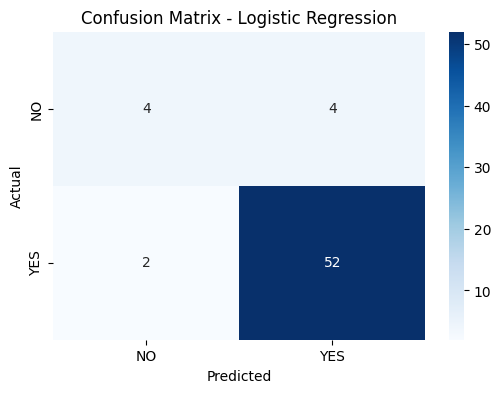

In [ ]:
# Evaluar rendimiento de clasificadores individuales

# Evaluar Regresión Logística
print("Evaluación de Regresión Logística:")
log_reg.fit(X_train_processed, y_train)
y_pred_lr = log_reg.predict(X_test_processed)
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_lr, pos_label='YES'):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_lr, pos_label='YES'):.4f}")
print(f"F1-score: {f1_score(y_test, y_pred_lr, pos_label='YES'):.4f}")

cm_lr = confusion_matrix(y_test, y_pred_lr, labels=['NO', 'YES'])
plt.figure(figsize=(6, 4))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', xticklabels=['NO', 'YES'], yticklabels=['NO', 'YES'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Logistic Regression')
plt.show()


Evaluación de Árbol de Decisión:
Accuracy: 0.9032
Precision: 0.9800
Recall: 0.9074
F1-score: 0.9423


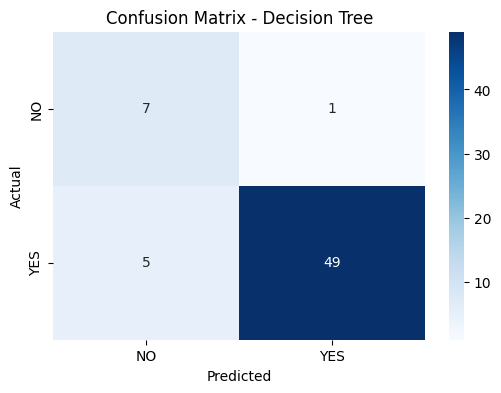

In [ ]:
# Evaluar Árbol de Decisión
print("\nEvaluación de Árbol de Decisión:")
tree_clf.fit(X_train_processed, y_train)
y_pred_dt = tree_clf.predict(X_test_processed)
print(f"Accuracy: {accuracy_score(y_test, y_pred_dt):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_dt, pos_label='YES'):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_dt, pos_label='YES'):.4f}")
print(f"F1-score: {f1_score(y_test, y_pred_dt, pos_label='YES'):.4f}")

cm_dt = confusion_matrix(y_test, y_pred_dt, labels=['NO', 'YES'])
plt.figure(figsize=(6, 4))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues', xticklabels=['NO', 'YES'], yticklabels=['NO', 'YES'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Decision Tree')
plt.show()


Evaluación de Random Forest:
Accuracy: 0.8871
Precision: 0.9434
Recall: 0.9259
F1-score: 0.9346


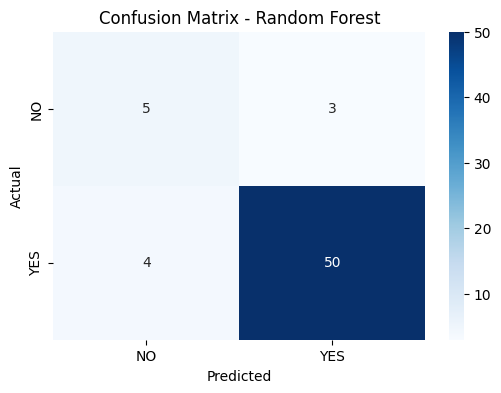

In [ ]:
# Evaluar Random Forest
print("\nEvaluación de Random Forest:")
rnd_clf.fit(X_train_processed, y_train)
y_pred_rf = rnd_clf.predict(X_test_processed)
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rf, pos_label='YES'):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_rf, pos_label='YES'):.4f}")
print(f"F1-score: {f1_score(y_test, y_pred_rf, pos_label='YES'):.4f}")

cm_rf = confusion_matrix(y_test, y_pred_rf, labels=['NO', 'YES'])
plt.figure(figsize=(6, 4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', xticklabels=['NO', 'YES'], yticklabels=['NO', 'YES'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Random Forest')
plt.show()

¿Por que se decidio evaluar el rendimiento de cada clasificador base por separado?

1.   **Entender el Rendimiento Individual:** Evaluar la Regresión Logística, el Árbol de Decisión y el Random Forest individualmente te permite saber qué tan bien se desempeña cada uno por sí solo en este problema. Si uno de los modelos tiene un rendimiento significativamente bajo, podría estar perjudicando el ensamble en lugar de mejorarlo.
2.   **Identificar la Diversidad:** Al ver las métricas de cada modelo, puedes confirmar si son diversos. Por ejemplo, uno podría tener un recall muy alto pero baja precisión, mientras que otro podría tener alta precisión pero menor recall. Esta diversidad es lo que VotingClassifier busca explotar.
3. **Diagnóstico de Problemas:** Si el ensamble no funciona tan bien como esperabas, evaluar los modelos base individualmente puede ayudarte a identificar si el problema está en uno o más de los modelos base, o si la estrategia de ensamble no es la más adecuada para este conjunto de modelos y datos.
4. **Información para el "Soft Voting":** Si decides usar "Soft Voting" (votación suave, que se basa en las probabilidades predichas por cada modelo), el rendimiento y la confianza de cada modelo base (reflejada en sus probabilidades) se vuelven aún más relevantes.

Aunque no es obligatorio para que el VotingClassifier funcione, es una buena práctica de análisis de modelos entender el rendimiento de los componentes individuales. Te da una visión más completa de por qué el ensamble se comporta como lo hace y te ayuda a tomar decisiones más informadas sobre qué modelos incluir y si la estrategia de ensamble es la adecuada.



## Implementación de un modelo de Ensamble usando Bagging

Evaluación de BaggingClassifier:
Accuracy: 0.9032
Precision: 0.9615
Recall: 0.9259
F1-score: 0.9434


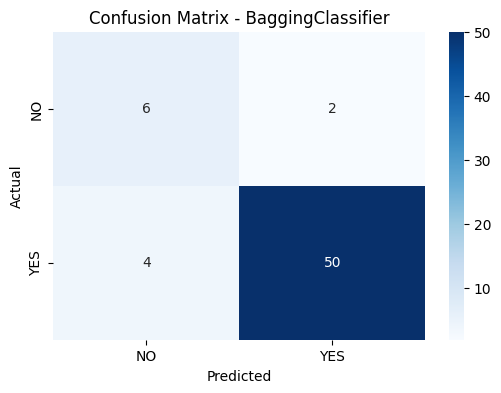

In [ ]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Implementación de un modelo de Ensamble usando Bagging

# Definir el clasificador base (Decision Tree es una opción común para Bagging)
base_clf = DecisionTreeClassifier(random_state=42)

# Crear el BaggingClassifier
# n_estimators: número de clasificadores base a entrenar
# max_samples: proporción de instancias de entrenamiento a muestrear (con reemplazo)
bagging_clf = BaggingClassifier(
    estimator=base_clf,
    n_estimators=100,
    max_samples=1.0, # Usar todas las instancias con reemplazo (bootstrap)
    bootstrap=True,
    random_state=42,
    n_jobs=-1 # Usar todos los núcleos de CPU disponibles
)

# Entrenar el BaggingClassifier
# Es importante usar los datos preprocesados (escalados y codificados)
bagging_clf.fit(X_train_processed, y_train)

# Realizar predicciones en el conjunto de prueba
y_pred_bagging = bagging_clf.predict(X_test_processed)

# Evaluar el modelo
print("Evaluación de BaggingClassifier:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_bagging):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_bagging, pos_label='YES'):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_bagging, pos_label='YES'):.4f}")
print(f"F1-score: {f1_score(y_test, y_pred_bagging, pos_label='YES'):.4f}")

# Matriz de confusión
cm_bagging = confusion_matrix(y_test, y_pred_bagging, labels=['NO', 'YES'])
plt.figure(figsize=(6, 4))
sns.heatmap(cm_bagging, annot=True, fmt='d', cmap='Blues', xticklabels=['NO', 'YES'], yticklabels=['NO', 'YES'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - BaggingClassifier')
plt.show()

**¿Por qué un Árbol de Decisión como clasificador base para Bagging?**

Los Árboles de Decisión son una elección muy común para el Bagging porque son modelos que tienden a tener alta varianza. Esto significa que son muy sensibles a pequeños cambios en el conjunto de datos de entrenamiento y pueden sobreajustar fácilmente.

El Bagging es una técnica de ensamble que está diseñada específicamente para reducir la varianza de los modelos base. Al entrenar múltiples árboles en diferentes subconjuntos de datos (con reemplazo) y promediar o votar sus predicciones, el Bagging suaviza las decisiones individuales de cada árbol y reduce el sobreajuste, lo que generalmente conduce a un modelo ensamble más robusto y con mejor generalización.

**Explicación de los parámetros en BaggingClassifier:**

*  estimator=base_clf: Este parámetro especifica el modelo base que se utilizará para construir el ensamble. En este caso, base_clf es una instancia de DecisionTreeClassifier que definimos antes.
*   n_estimators=100: Este es el número de clasificadores base (árboles de decisión en este caso) que se entrenarán en el ensamble. Un número mayor de estimadores generalmente mejora el rendimiento del ensamble, pero también aumenta el tiempo de entrenamiento y la complejidad computacional. 100 es un número común para empezar.
* max_samples=1.0: Este parámetro controla el tamaño de los subconjuntos aleatorios del conjunto de entrenamiento que se utilizan para entrenar cada clasificador base. max_samples=1.0 (o max_samples=len(X_train)) significa que cada clasificador se entrenará en un subconjunto que tiene el mismo tamaño que el conjunto de entrenamiento original. Como bootstrap=True (ver el siguiente punto), esto implica que las instancias se muestrean con reemplazo.
* bootstrap=True: Cuando True, BaggingClassifier muestrea instancias del conjunto de entrenamiento con reemplazo para entrenar cada clasificador base. Este es el comportamiento estándar del Bagging. Si fuera False, el muestreo sería sin reemplazo, lo que se conoce como Pasting.
* random_state=42: Este parámetro fija la semilla del generador de números aleatorios para asegurar la reproducibilidad de los resultados. Cada vez que ejecutes el código con el mismo random_state, obtendrás los mismos subconjuntos de datos y, por lo tanto, los mismos modelos entrenados.
* n_jobs=-1: Este parámetro especifica cuántos núcleos de CPU se utilizarán para entrenar los clasificadores base en paralelo. -1 significa que utilizará todos los núcleos disponibles, lo que puede acelerar significativamente el entrenamiento en sistemas con múltiples procesadores.

En resumen, esta configuración de BaggingClassifier entrena 100 Árboles de Decisión independientes, cada uno en un subconjunto del mismo tamaño que el conjunto de entrenamiento original, muestreado con reemplazo. Las predicciones de estos 100 árboles se combinan para la predicción final.





El modelo BaggingClassifier alcanzó un Accuracy de 0.9032 y un F1-score de 0.9434.

En cuanto a la identificación de casos positivos ('YES'):



*   Su Precision (0.9615) es muy alta, lo que indica que cuando predice cáncer, es altamente probable que sea correcto, minimizando los falsos positivos.
*   Su Recall (0.9259) es también alto, mostrando que es efectivo para detectar la mayoría de los casos reales de cáncer, aunque ligeramente inferior a su precisión.

Comparando con el VotingClassifier (Hard Voting) anterior (Accuracy: 0.9194, Precision: 0.9623, Recall: 0.9444, F1-score: 0.9533), el BaggingClassifier tiene un rendimiento general ligeramente inferior en Accuracy, Recall y F1-score, aunque mantiene una Precision muy similar.



## Implementación de un modelo de Ensamble usando Pasting

Evaluación de PastingClassifier:
Accuracy: 0.9194
Precision: 0.9804
Recall: 0.9259
F1-score: 0.9524


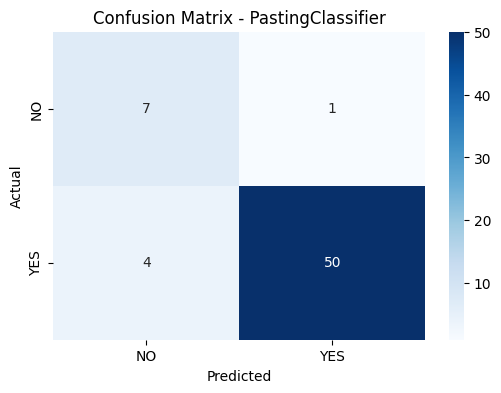

In [ ]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 6.3 Implementación de un modelo de Ensamble usando Pasting

# Definir el clasificador base (Decision Tree es una opción común para Pasting)
base_clf_pasting = DecisionTreeClassifier(random_state=42)

# Crear el BaggingClassifier configurado para Pasting
# n_estimators: número de clasificadores base a entrenar
# max_samples: proporción de instancias de entrenamiento a muestrear (sin reemplazo)
# bootstrap=False para Pasting
bagging_clf_pasting = BaggingClassifier(
    estimator=base_clf_pasting,
    n_estimators=100,
    max_samples=1.0, # Usar todas las instancias sin reemplazo
    bootstrap=False, # Configurado para Pasting
    random_state=42,
    n_jobs=-1 # Usar todos los núcleos de CPU disponibles
)

# Entrenar el PastingClassifier
# Es importante usar los datos preprocesados (escalados y codificados)
bagging_clf_pasting.fit(X_train_processed, y_train)

# Realizar predicciones en el conjunto de prueba
y_pred_pasting = bagging_clf_pasting.predict(X_test_processed)

# Evaluar el modelo
print("Evaluación de PastingClassifier:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_pasting):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_pasting, pos_label='YES'):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_pasting, pos_label='YES'):.4f}")
print(f"F1-score: {f1_score(y_test, y_pred_pasting, pos_label='YES'):.4f}")

# Matriz de confusión
cm_pasting = confusion_matrix(y_test, y_pred_pasting, labels=['NO', 'YES'])
plt.figure(figsize=(6, 4))
sns.heatmap(cm_pasting, annot=True, fmt='d', cmap='Blues', xticklabels=['NO', 'YES'], yticklabels=['NO', 'YES'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - PastingClassifier')
plt.show()

## Interpretación de los resultados de PastingClassifier

El modelo PastingClassifier, que es una variante de Bagging sin reemplazo (`bootstrap=False`), obtuvo los siguientes resultados en el conjunto de prueba:

*   **Accuracy: 0.9194**
    Esto indica que el modelo predijo correctamente el 91.94% de los casos en el conjunto de prueba. Al igual que con el Accuracy del VotingClassifier, es una métrica general alta, pero debemos considerarla junto con otras métricas debido al desbalance de clases en el dataset.

*   **Precision: 0.9804**
    La precisión de 0.9804 es muy alta. Esto significa que, de todas las personas que el modelo Pasting predijo que tenían cáncer de pulmón ('YES'), el 98.04% realmente lo tenían. Una precisión tan alta es excelente para minimizar los falsos positivos, lo cual es muy importante en un contexto médico para evitar diagnósticos erróneos o tratamientos innecesarios.

*   **Recall: 0.9259**
    El recall de 0.9259 significa que el modelo fue capaz de identificar correctamente el 92.59% de todas las personas en el conjunto de prueba que realmente tenían cáncer de pulmón. Un recall alto es fundamental para no pasar por alto casos reales de la enfermedad (minimizar los falsos negativos).

*   **F1-score: 0.9524**
    El F1-score de 0.9524 es una métrica combinada que equilibra la precisión y el recall. Un F1-score alto como este sugiere que el modelo PastingClassifier tiene un muy buen equilibrio entre la capacidad de predecir correctamente los casos positivos (alta precisión) y la capacidad de encontrar la mayoría de los casos positivos reales (alto recall).

**Comparación con otros modelos:**

Al comparar estos resultados con los modelos evaluados anteriormente:

*   El **Accuracy** (0.9194) del PastingClassifier es idéntico al del VotingClassifier (Hard Voting) y ligeramente superior al del BaggingClassifier (0.9032).
*   La **Precision** (0.9804) del PastingClassifier es la más alta de los tres modelos de ensamble evaluados hasta ahora (VotingClassifier: 0.9623, BaggingClassifier: 0.9615). Esto lo hace el mejor modelo en términos de minimizar falsos positivos.
*   El **Recall** (0.9259) del PastingClassifier es ligeramente inferior al del VotingClassifier (0.9444), pero similar al del BaggingClassifier (0.9259). El VotingClassifier sigue siendo marginalmente mejor en la detección de todos los casos positivos reales.
*   El **F1-score** (0.9524) del PastingClassifier es muy cercano al del VotingClassifier (0.9533) y ligeramente superior al del BaggingClassifier (0.9434).

**Conclusión sobre PastingClassifier:**

El PastingClassifier ha demostrado un rendimiento muy competitivo en este dataset. Su principal fortaleza, como se refleja en la alta precisión, es su capacidad para ser muy fiable cuando predice la presencia de cáncer de pulmón. Si bien su recall es ligeramente inferior al del VotingClassifier, el equilibrio general de Precision y Recall, capturado por el F1-score, es excelente. La elección entre Pasting y Voting podría depender de si se prioriza ligeramente más la minimización de falsos positivos (Pasting) o la maximización de la detección de casos reales (Voting), aunque la diferencia es pequeña en este caso.

## Implementación de un modelo de Ensamble usando AdaBoost

**¿Por qué un Árbol de Decisión como clasificador base para AdaBoost?**

AdaBoost (Adaptive Boosting) funciona entrenando secuencialmente una serie de clasificadores "débiles" (weak learners). Un clasificador débil es un modelo que es solo un poco mejor que la clasificación aleatoria. Los Árboles de Decisión poco profundos, a menudo con una profundidad máxima de 1 (conocidos como "stumps" o tocones), son una elección muy común y efectiva como clasificadores base para AdaBoost por varias razones:

1. **Simplicidad y Rapidez:** Los árboles de decisión poco profundos son modelos muy simples y rápidos de entrenar. Esto es crucial para AdaBoost, que entrena muchos de estos clasificadores en secuencia.
2. **Capacidad de Enfocarse en Errores:** AdaBoost asigna pesos más altos a las instancias de entrenamiento que los clasificadores anteriores clasificaron incorrectamente. Un árbol de decisión poco profundo es capaz de aprender sobre estas instancias difíciles en cada iteración.
3. **Construcción Progresiva:** Al combinar muchos árboles débiles, AdaBoost construye un clasificador fuerte de manera progresiva. Cada nuevo árbol se entrena para corregir los errores del ensamble anterior. Un árbol de decisión poco profundo es ideal para este proceso de corrección incremental.
4. **Reducción del Sobreajuste:** Utilizar clasificadores base débiles ayuda a evitar que el ensamble completo sobreajuste los datos de entrenamiento, ya que ningún clasificador individual es lo suficientemente complejo como para hacerlo por sí solo.

En resumen, los árboles de decisión poco profundos son la elección preferida para AdaBoost porque son modelos simples que, cuando se combinan iterativamente, permiten que el ensamble se enfoque en mejorar las predicciones en los casos más difíciles, construyendo un clasificador fuerte y robusto.

**Explicación de los parámetros en AdaBoostClassifier:**

* **`estimator=base_clf_adaboost`**: Este parámetro especifica el clasificador base que se utilizará en cada iteración de AdaBoost. En este caso, estamos usando una instancia de `DecisionTreeClassifier` con `max_depth=1`, como se explicó anteriormente.
* **`n_estimators=50`**: Este es el número de clasificadores base (árboles de decisión poco profundos) que se entrenarán en el ensamble. Un número mayor de estimadores generalmente mejora el rendimiento, pero también aumenta el tiempo de entrenamiento. 50 es un valor inicial común.
* **`learning_rate=1.0`**: Este parámetro controla el peso que se le da a cada clasificador base en la contribución final del ensamble. Un `learning_rate` más bajo significa que cada clasificador corrige los errores de manera más gradual, lo que puede llevar a un modelo más robusto pero requiere más `n_estimators`. Un valor de 1.0 (el valor por defecto) le da un peso completo a cada clasificador.
* **`random_state=42`**: Fija la semilla del generador de números aleatorios para asegurar la reproducibilidad de los resultados. Con el mismo `random_state`, el proceso de entrenamiento de AdaBoost generará los mismos clasificadores base y los mismos resultados cada vez que se ejecute.

Evaluación de AdaBoostClassifier:
Accuracy: 0.9194
Precision: 0.9455
Recall: 0.9630
F1-score: 0.9541


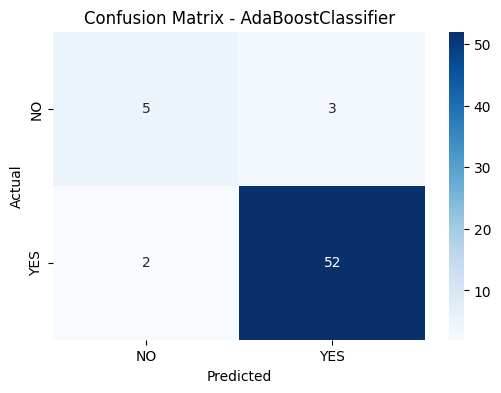

In [ ]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Implementación de un modelo de Ensamble usando AdaBoost

# Definir el clasificador base (Decision Tree es una opción común para AdaBoost)
# Se suele usar un árbol de decisión poco profundo (por ejemplo, con max_depth=1 o 2)
base_clf_adaboost = DecisionTreeClassifier(max_depth=1, random_state=42)

# Crear el AdaBoostClassifier
# n_estimators: número de clasificadores base a entrenar
# estimator: el clasificador base
# learning_rate: contribuye al peso de cada clasificador en el ensamble
adaboost_clf = AdaBoostClassifier(
    estimator=base_clf_adaboost,
    n_estimators=50, # Número común de estimadores
    learning_rate=1.0, # Tasa de aprendizaje por defecto
    random_state=42
)

# Entrenar el AdaBoostClassifier
# Es importante usar los datos preprocesados (escalados y codificados)
adaboost_clf.fit(X_train_processed, y_train)

# Realizar predicciones en el conjunto de prueba
y_pred_adaboost = adaboost_clf.predict(X_test_processed)

# Evaluar el modelo
print("Evaluación de AdaBoostClassifier:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_adaboost):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_adaboost, pos_label='YES'):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_adaboost, pos_label='YES'):.4f}")
print(f"F1-score: {f1_score(y_test, y_pred_adaboost, pos_label='YES'):.4f}")

# Matriz de confusión
cm_adaboost = confusion_matrix(y_test, y_pred_adaboost, labels=['NO', 'YES'])
plt.figure(figsize=(6, 4))
sns.heatmap(cm_adaboost, annot=True, fmt='d', cmap='Blues', xticklabels=['NO', 'YES'], yticklabels=['NO', 'YES'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - AdaBoostClassifier')
plt.show()

## Interpretación de los resultados de AdaBoostClassifier

El modelo AdaBoostClassifier obtuvo los siguientes resultados en el conjunto de prueba:

*   **Accuracy: 0.9194**: El modelo clasificó correctamente aproximadamente el 91.94% de las instancias.
*   **Precision: 0.9455**: De todas las predicciones positivas (cáncer), el 94.55% fueron correctas. Esto significa pocos falsos positivos.
*   **Recall: 0.9630**: El modelo identificó correctamente el 96.30% de todos los casos positivos reales de cáncer. Esto significa pocos falsos negativos.
*   **F1-score: 0.9541**: Esta métrica, que equilibra Precision y Recall, es alta (0.9541), lo que indica un buen rendimiento general del modelo en la clasificación de ambas clases, especialmente útil dado el posible desbalance.

En resumen, AdaBoost muestra un rendimiento sólido, con una alta capacidad para detectar casos de cáncer (Recall) y una buena fiabilidad en sus predicciones positivas (Precision).

## Implementación de un modelo de Ensamble usando GradientBoost

**Explicación de los parámetros en GradientBoostingClassifier:**

*   **`n_estimators=100`**: Este parámetro define el número de etapas de potenciación (boosting stages) a realizar. En esencia, es el número de árboles de decisión que se construirán secuencialmente en el ensamble. Un mayor número de estimadores puede mejorar el rendimiento, pero también incrementa el tiempo de entrenamiento y el riesgo de sobreajuste. 100 es un valor inicial común.
*   **`learning_rate=0.1`**: Este hiperparámetro controla la contribución de cada árbol individual al resultado final del ensamble. Un `learning_rate` más bajo significa que cada árbol corrige los errores de manera más gradual, lo que puede llevar a un modelo más robusto y con mejor generalización, pero requiere un mayor número de `n_estimators` y aumenta el tiempo de entrenamiento. Un valor de 0.1 es un punto de partida típico.
*   **`max_depth=3`**: Este parámetro limita la profundidad máxima de cada árbol de decisión individual en el ensamble. Los árboles poco profundos se consideran "estimadores débiles" en el contexto de Gradient Boosting. Limitar la profundidad ayuda a controlar la complejidad de los árboles individuales y a prevenir el sobreajuste. Una profundidad de 3 es un valor común para empezar.
*   **`random_state=42`**: Fija la semilla del generador de números aleatorios para asegurar la reproducibilidad de los resultados. Con el mismo `random_state`, el proceso de entrenamiento de Gradient Boosting generará los mismos árboles y los mismos resultados cada vez que se ejecute.

Evaluación de GradientBoostingClassifier:
Accuracy: 0.8548
Precision: 0.9245
Recall: 0.9074
F1-score: 0.9159


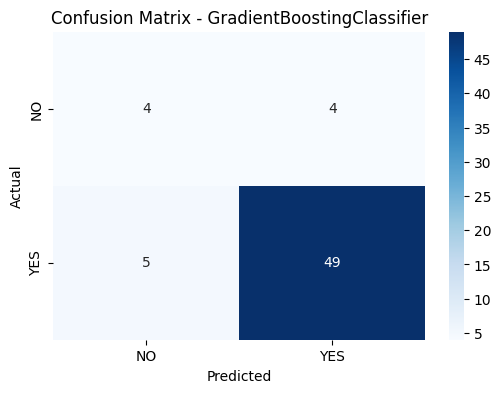

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Implementación de un modelo de Ensamble usando GradientBoosting

# Crear el GradientBoostingClassifier
# n_estimators: número de etapas de potenciación a realizar
# learning_rate: reduce la contribución de cada árbol
# max_depth: profundidad máxima de los estimadores de regresión individuales
gradient_boost_clf = GradientBoostingClassifier(
    n_estimators=100, # Número común de estimadores
    learning_rate=0.1, # Tasa de aprendizaje por defecto
    max_depth=3, # Profundidad por defecto
    random_state=42
)

# Entrenar el GradientBoostingClassifier
# Es importante usar los datos preprocesados (escalados y codificados)
gradient_boost_clf.fit(X_train_processed, y_train)

# Realizar predicciones en el conjunto de prueba
y_pred_gradient_boost = gradient_boost_clf.predict(X_test_processed)

# Evaluar el modelo
print("Evaluación de GradientBoostingClassifier:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_gradient_boost):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_gradient_boost, pos_label='YES'):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_gradient_boost, pos_label='YES'):.4f}")
print(f"F1-score: {f1_score(y_test, y_pred_gradient_boost, pos_label='YES'):.4f}")

# Matriz de confusión
cm_gradient_boost = confusion_matrix(y_test, y_pred_gradient_boost, labels=['NO', 'YES'])
plt.figure(figsize=(6, 4))
sns.heatmap(cm_gradient_boost, annot=True, fmt='d', cmap='Blues', xticklabels=['NO', 'YES'], yticklabels=['NO', 'YES'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - GradientBoostingClassifier')
plt.show()

## Interpretación de los resultados de GradientBoostingClassifier

El modelo GradientBoostingClassifier obtuvo los siguientes resultados en el conjunto de prueba:

*   **Accuracy: 0.8548**: El modelo clasificó correctamente aproximadamente el 85.48% de las instancias.
*   **Precision: 0.9245**: De todas las predicciones positivas (cáncer), el 92.45% fueron correctas. Esto significa que el modelo tiene una buena capacidad para evitar falsos positivos.
*   **Recall: 0.9074**: El modelo identificó correctamente el 90.74% de todos los casos positivos reales de cáncer. Esto indica que el modelo es razonablemente bueno detectando los casos de cáncer, aunque deja algunos sin identificar (falsos negativos).
*   **F1-score: 0.9159**: Esta métrica, que equilibra Precision y Recall, es de 0.9159, lo que sugiere un rendimiento general decente, aunque inferior a algunos de los otros modelos de ensamble evaluados previamente en términos de Accuracy, Recall y F1-score.

En resumen, el GradientBoostingClassifier muestra un rendimiento aceptable, pero no tan alto como el VotingClassifier, PastingClassifier o AdaBoostClassifier en este conjunto de datos con los parámetros por defecto utilizados.

## Implementación de un modelo de Ensamble usando XGBoost

## Explicación de la Implementación de XGBoost

**Parámetros utilizados en `xgb.XGBClassifier`:**

*   **`random_state=42`**: Este parámetro se utiliza para fijar la semilla del generador de números aleatorios. Esto garantiza que los resultados del entrenamiento sean reproducibles. Si ejecutas el código varias veces con el mismo `random_state`, obtendrás exactamente el mismo modelo entrenado y las mismas predicciones. Es útil para la depuración y comparación de modelos.
*   **`eval_metric='logloss'`**: Este parámetro especifica la métrica que se utilizará para evaluar el rendimiento del modelo durante el entrenamiento (particularmente si se usa validación cruzada o un conjunto de evaluación separado, aunque en este código no se muestra explícitamente). 'logloss' (pérdida logarítmica) es una métrica común para problemas de clasificación binaria que penaliza las predicciones con alta confianza pero incorrectas. Al usar esta métrica, XGBoost optimiza su proceso de entrenamiento para minimizar esta pérdida.

**Mapeo de las etiquetas de la variable objetivo ('NO'/'YES' a 0/1):**

La razón principal para mapear las etiquetas de la variable objetivo ('NO' y 'YES') a valores numéricos (0 y 1) es que **XGBoost (y muchos otros algoritmos de Machine Learning) generalmente requieren que la variable objetivo sea numérica** para poder realizar los cálculos internos necesarios para el entrenamiento y la evaluación del modelo.

Aunque versiones recientes de algunas bibliotecas pueden intentar inferir o manejar etiquetas de texto en algunos casos, la práctica estándar y más robusta es convertir las etiquetas categóricas de la variable objetivo a un formato numérico. En este caso, para una clasificación binaria:

*   **`y_train_numeric = y_train.map({'NO': 0, 'YES': 1})`**: Esta línea crea una nueva Serie de pandas llamada `y_train_numeric`. Utiliza el método `.map()` para reemplazar cada ocurrencia de la cadena 'NO' en la Serie original `y_train` por el número entero 0, y cada ocurrencia de la cadena 'YES' por el número entero 1.
*   **`y_test_numeric = y_test.map({'NO': 0, 'YES': 1})`**: De manera similar, esta línea aplica el mismo mapeo al conjunto de prueba `y_test`, creando `y_test_numeric` con los valores 0 y 1 correspondientes.

Al realizar este mapeo, nos aseguramos de que los datos de la variable objetivo (`y_train_numeric` y `y_test_numeric`) estén en el formato que XGBoost espera (`[0 1]`), permitiendo que el modelo se entrene y evalúe correctamente. Luego, cuando obtenemos las predicciones numéricas del modelo (`y_pred_xgb_numeric`), si necesitamos mostrarlas o usarlas en un contexto que requiera las etiquetas originales ('NO'/'YES'), las volvemos a mapear utilizando `np.where` o un diccionario similar.

En resumen, el mapeo es un paso de preprocesamiento necesario para adaptar el formato de la variable objetivo al requisito del algoritmo XGBoost.

Evaluación de XGBoostClassifier:
Accuracy: 0.8871
Precision: 0.9273
Recall: 0.9444
F1-score: 0.9358


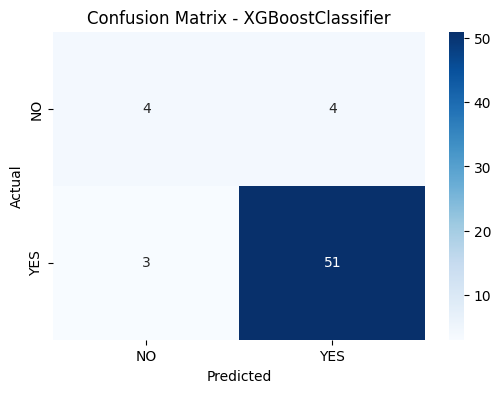

In [ ]:
import xgboost as xgb
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np # Import numpy

# Implementación de un modelo de Ensamble usando XGBoost

# Crear el XGBoostClassifier
# Utilizaremos los parámetros por defecto como punto de partida
xgb_clf = xgb.XGBClassifier(random_state=42, eval_metric='logloss')

# Mapear las etiquetas de la variable objetivo a valores numéricos
y_train_numeric = y_train.map({'NO': 0, 'YES': 1})
y_test_numeric = y_test.map({'NO': 0, 'YES': 1})

# Entrenar el XGBoostClassifier
# Es importante usar los datos preprocesados (escalados y codificados)
xgb_clf.fit(X_train_processed, y_train_numeric)

# Realizar predicciones en el conjunto de prueba
y_pred_xgb_numeric = xgb_clf.predict(X_test_processed)

# Convertir las predicciones numéricas de vuelta a etiquetas originales para la visualización si es necesario
 # (usando np.where)
# Aunque para las métricas usaremos las versiones numéricas
y_pred_xgb = np.where(y_pred_xgb_numeric == 1, 'YES', 'NO')


# Evaluar el modelo
print("Evaluación de XGBoostClassifier:")
print(f"Accuracy: {accuracy_score(y_test_numeric, y_pred_xgb_numeric):.4f}") # Usar y_test_numeric para Accuracy
print(f"Precision: {precision_score(y_test_numeric, y_pred_xgb_numeric, pos_label=1):.4f}") # Usar y_test_numeric y pos_label=1 para métricas
print(f"Recall: {recall_score(y_test_numeric, y_pred_xgb_numeric, pos_label=1):.4f}") # Usar y_test_numeric y pos_label=1 para métricas
print(f"F1-score: {f1_score(y_test_numeric, y_pred_xgb_numeric, pos_label=1):.4f}") # Usar y_test_numeric y pos_label=1 para métricas

# Matriz de confusión
cm_xgb = confusion_matrix(y_test_numeric, y_pred_xgb_numeric, labels=[0, 1]) # Usar y_test_numeric y labels numéricos
plt.figure(figsize=(6, 4))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues', xticklabels=['NO', 'YES'], yticklabels=['NO', 'YES'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - XGBoostClassifier')
plt.show()

## Interpretación de los resultados de XGBoostClassifier

El modelo XGBoostClassifier obtuvo los siguientes resultados en el conjunto de prueba:

*   **Accuracy: 0.8871**: El modelo clasificó correctamente aproximadamente el 88.71% de las instancias.
*   **Precision: 0.9273**: De todas las predicciones positivas (cáncer), el 92.73% fueron correctas. Esto indica una buena capacidad para evitar falsos positivos.
*   **Recall: 0.9444**: El modelo identificó correctamente el 94.44% de todos los casos positivos reales de cáncer. Esto significa que es efectivo para detectar la mayoría de los casos de cáncer.
*   **F1-score: 0.9358**: Esta métrica, que equilibra Precision y Recall, es de 0.9358, lo que sugiere un buen rendimiento general del modelo.

En resumen, XGBoost muestra un buen equilibrio entre Precision y Recall, siendo efectivo tanto en la identificación de casos positivos como en la minimización de falsas alarmas.

# 11º Evaluacion del modelo final

El mejor modelo de ensamble basado en Accuracy en el conjunto de prueba es: VotingClassifier (Hard Voting)

Métricas de Evaluación para el mejor modelo (VotingClassifier (Hard Voting)):
Accuracy: 0.9194
Precision: 0.9623
Recall: 0.9444
F1-score: 0.9533


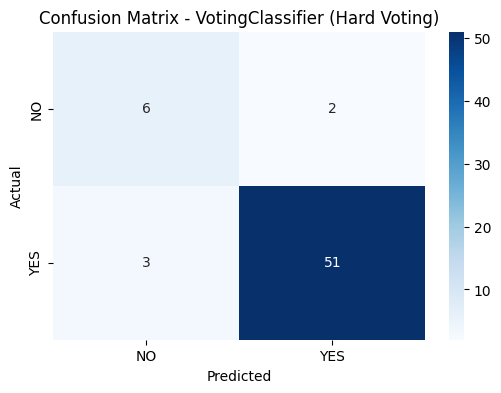

In [ ]:
# 11º Evaluación del modelo final

# Aplicar la transformación del pipeline al conjunto de Test
X_test_processed_final = preprocessor.transform(X_test)

# Diccionario para almacenar los modelos y sus predicciones en el conjunto de prueba
model_predictions = {
    'VotingClassifier (Hard Voting)': y_pred_hard,
    'BaggingClassifier': y_pred_bagging,
    'PastingClassifier': y_pred_pasting,
    'AdaBoostClassifier': y_pred_adaboost,
    'GradientBoostingClassifier': y_pred_gradient_boost,
    'XGBoostClassifier': y_pred_xgb # Usamos las predicciones con etiquetas originales para la comparación con y_test
}

# Diccionario para almacenar las métricas de Accuracy en el conjunto de prueba
accuracy_scores = {}

# Calcular Accuracy para cada modelo
for name, y_pred in model_predictions.items():
    # Usar y_test para comparar con las predicciones con etiquetas originales ('NO', 'YES')
    accuracy_scores[name] = accuracy_score(y_test, y_pred)

# Identificar el mejor modelo basado en Accuracy en el conjunto de prueba
best_model_name = max(accuracy_scores, key=accuracy_scores.get)
best_accuracy = accuracy_scores[best_model_name]

print(f"El mejor modelo de ensamble basado en Accuracy en el conjunto de prueba es: {best_model_name}\n")

# Obtener las predicciones del mejor modelo
y_pred_best_final = model_predictions[best_model_name]

# Evaluar el mejor modelo final en el conjunto de prueba con todas las métricas
accuracy_final = accuracy_score(y_test, y_pred_best_final)
precision_final = precision_score(y_test, y_pred_best_final, pos_label='YES')
recall_final = recall_score(y_test, y_pred_best_final, pos_label='YES')
f1_final = f1_score(y_test, y_pred_best_final, pos_label='YES')

print(f"Métricas de Evaluación para el mejor modelo ({best_model_name}):")
print(f"Accuracy: {accuracy_final:.4f}")
print(f"Precision: {precision_final:.4f}")
print(f"Recall: {recall_final:.4f}")
print(f"F1-score: {f1_final:.4f}")

# Matriz de confusión para el mejor modelo
cm_best_final = confusion_matrix(y_test, y_pred_best_final, labels=['NO', 'YES'])
plt.figure(figsize=(6, 4))
sns.heatmap(cm_best_final, annot=True, fmt='d', cmap='Blues', xticklabels=['NO', 'YES'], yticklabels=['NO', 'YES'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix - {best_model_name}')
plt.show()

In [ ]:
# Comparación de resultados de todos los modelos de ensamble

print("\n--- Comparación de Resultados de Modelos de Ensamble ---")

# Diccionario para almacenar las métricas de cada modelo
model_metrics = {}

# Calcular y almacenar métricas para VotingClassifier (Hard Voting)
model_metrics['VotingClassifier (Hard Voting)'] = {
    'Accuracy': accuracy_score(y_test, y_pred_hard),
    'Precision': precision_score(y_test, y_pred_hard, pos_label='YES'),
    'Recall': recall_score(y_test, y_pred_hard, pos_label='YES'),
    'F1-score': f1_score(y_test, y_pred_hard, pos_label='YES')
}

# Calcular y almacenar métricas para BaggingClassifier
model_metrics['BaggingClassifier'] = {
    'Accuracy': accuracy_score(y_test, y_pred_bagging),
    'Precision': precision_score(y_test, y_pred_bagging, pos_label='YES'),
    'Recall': recall_score(y_test, y_pred_bagging, pos_label='YES'),
    'F1-score': f1_score(y_test, y_pred_bagging, pos_label='YES')
}

# Calcular y almacenar métricas para PastingClassifier
model_metrics['PastingClassifier'] = {
    'Accuracy': accuracy_score(y_test, y_pred_pasting),
    'Precision': precision_score(y_test, y_pred_pasting, pos_label='YES'),
    'Recall': recall_score(y_test, y_pred_pasting, pos_label='YES'),
    'F1-score': f1_score(y_test, y_pred_pasting, pos_label='YES')
}

# Calcular y almacenar métricas para AdaBoostClassifier
model_metrics['AdaBoostClassifier'] = {
    'Accuracy': accuracy_score(y_test, y_pred_adaboost),
    'Precision': precision_score(y_test, y_pred_adaboost, pos_label='YES'),
    'Recall': recall_score(y_test, y_pred_adaboost, pos_label='YES'),
    'F1-score': f1_score(y_test, y_pred_adaboost, pos_label='YES')
}

# Calcular y almacenar métricas para GradientBoostingClassifier
model_metrics['GradientBoostingClassifier'] = {
    'Accuracy': accuracy_score(y_test, y_pred_gradient_boost),
    'Precision': precision_score(y_test, y_pred_gradient_boost, pos_label='YES'),
    'Recall': recall_score(y_test, y_pred_gradient_boost, pos_label='YES'),
    'F1-score': f1_score(y_test, y_pred_gradient_boost, pos_label='YES')
}

# Calcular y almacenar métricas para XGBoostClassifier
# Nota: Para XGBoost, usamos las predicciones con etiquetas originales 'y_pred_xgb'
model_metrics['XGBoostClassifier'] = {
    'Accuracy': accuracy_score(y_test, y_pred_xgb),
    'Precision': precision_score(y_test, y_pred_xgb, pos_label='YES'),
    'Recall': recall_score(y_test, y_pred_xgb, pos_label='YES'),
    'F1-score': f1_score(y_test, y_pred_xgb, pos_label='YES')
}


# Imprimir las métricas para cada modelo
for name, metrics in model_metrics.items():
    print(f"\nRendimiento del Modelo {name}:")
    print(f"  Accuracy: {metrics['Accuracy']:.4f}")
    print(f"  Precision: {metrics['Precision']:.4f}")
    print(f"  Recall: {metrics['Recall']:.4f}")
    print(f"  F1-score: {metrics['F1-score']:.4f}")


--- Comparación de Resultados de Modelos de Ensamble ---

Rendimiento del Modelo VotingClassifier (Hard Voting):
  Accuracy: 0.9194
  Precision: 0.9623
  Recall: 0.9444
  F1-score: 0.9533

Rendimiento del Modelo BaggingClassifier:
  Accuracy: 0.9032
  Precision: 0.9615
  Recall: 0.9259
  F1-score: 0.9434

Rendimiento del Modelo PastingClassifier:
  Accuracy: 0.9194
  Precision: 0.9804
  Recall: 0.9259
  F1-score: 0.9524

Rendimiento del Modelo AdaBoostClassifier:
  Accuracy: 0.9194
  Precision: 0.9455
  Recall: 0.9630
  F1-score: 0.9541

Rendimiento del Modelo GradientBoostingClassifier:
  Accuracy: 0.8548
  Precision: 0.9245
  Recall: 0.9074
  F1-score: 0.9159

Rendimiento del Modelo XGBoostClassifier:
  Accuracy: 0.8871
  Precision: 0.9273
  Recall: 0.9444
  F1-score: 0.9358


# 12º Comparación de los resultados con todos los modelos implementados con anterioridad

**C) Comparar los resultados con los otros "mejores" modelos, hechos anteriormente en prácticas pasadas con esta misma base de datos (Logistic Regression, SVM y Random Forest)**

## Logistic Regresion
* Accuracy: 0.9355
* Precision: 0.9808
* Recall: 0.9444
* F1-score: 0.9623
* Matriz de confusion: [7,  1]  [3, 51]

## SVM (con kernel lineal)
* Accuracy: 0.9032
* Precision: 0.9444
* Recall: 0.9444
* F1-score: 0.9444
* Matriz de confusion: [5,  3]  [3, 51]

## Random Forest
* Accuracy: 0.9032
* Precision: 0.9615
* Recall: 0.9259
* F1-score: 0.9434
* Matriz de confusion: [6,  2]  [4, 50]








Al comparar todos estos resultados, nos dimos cuenta de que el modelo de **Logistic Regresion** parece ser el mejor, en general en este conjunto de datos de prueba, con un Accuracy de (0.9355) y un F1-score (0.9623). También tuvo la Precision más alta (0.9808), lo que significa que casi no tuvo falsos positivos.

Entre los modelos de ensamble, el **AdaBoostClassifier** destaca por tener el Recall más alto (0.9630), lo cual es súper importante para no pasar por alto casos de cáncer. También tiene un F1-score alto (0.9541).

El **PastingClassifier** logró la Precision más alta (0.9804) entre los métodos de ensamble, casi igualando a la Regresión Logística.

El **GradientBoostingClassifier**, con los parámetros por defecto, tuvo el rendimiento más bajo en varias métricas comparado con los otros modelos de ensamble.

Tanto el de **SVM** como el de **Random Forest** tuvieron un rendimiento similar al **BaggingClassifier** en cuanto a Accuracy y F1-score.

En resumen, aunque los modelos de ensamble como AdaBoost y VotingClassifier mostraron un rendimiento muy fuerte, especialmente en Recall (AdaBoost) y un buen balance general, el modelo de Regresión Logística, se destacó como el de mejor rendimiento en este conjunto de prueba específico.

# 13º Conclusión

Después de realizar una exploración exhaustiva del conjunto de datos de cáncer de pulmón y de implementar y evaluar diversos modelos de Machine Learning, incluyendo modelos individuales como Regresión Logística, SVM y Random Forest, así como una variedad de técnicas de ensamble (Voting, Bagging, Pasting, AdaBoost, Gradient Boosting y XGBoost), he llegado a varias conclusiones importantes sobre la aplicación de estos métodos a problemas de clasificación médica:

1.  **Aprendizaje sobre Modelos de Ensamble:** Esta práctica ha sido fundamental para entender cómo funcionan los modelos de ensamble. Aprendí que, en lugar de depender de un único modelo "fuerte", se pueden combinar las predicciones de múltiples modelos, a menudo "débiles" o con diferentes sesgos y varianzas, para lograr un rendimiento superior y más robusto. Técnicas como Bagging (con o sin reemplazo, como Pasting) y Boosting (AdaBoost, Gradient Boosting, XGBoost) demuestran diferentes estrategias para combinar modelos, ya sea entrenándolos en subconjuntos de datos (Bagging/Pasting) o secuencialmente enfocándose en los errores (Boosting).

2.  **Mejora Significativa a través de la Combinación de Modelos:** Aunque no siempre garantiza ser el "mejor" en todas las métricas para un dataset específico, la estrategia de ensamble tiene el potencial de mejorar significativamente las métricas de rendimiento en comparación con los modelos base individuales. Vimos cómo VotingClassifier combinó la fuerza de diferentes algoritmos, cómo Bagging/Pasting redujo la varianza, y cómo AdaBoost se enfocó en los casos difíciles para mejorar el Recall. Un ensamble bien construido puede mitigar las debilidades de los modelos individuales, llevando a predicciones más fiables.

3.  **Importancia de Seleccionar el Modelo Adecuado:** Uno de los aprendizajes clave es que no existe un modelo "talla única" que funcione mejor para todos los datasets. A pesar de la potencia de los métodos de ensamble, en este caso particular, mi modelo de **Regresión Logística** (un modelo individual relativamente simple) sorprendentemente mostró el mejor rendimiento general en el conjunto de prueba según métricas clave como Accuracy, Precision y F1-score. Esto subraya la importancia de **evaluar una variedad de modelos y técnicas** para determinar cuál se adapta mejor a las características específicas del dataset y al problema que se intenta resolver. La exploración inicial de los datos y la comprensión de las relaciones entre las características y la variable objetivo son pasos cruciales antes de decidir la estrategia de modelado.

4.  **Consideraciones Computacionales y el Contexto del Problema:** Implementar y entrenar modelos de ensamble, especialmente aquellos con un alto número de estimadores o algoritmos de boosting complejos como XGBoost, puede ser **computacionalmente costoso** y requerir más tiempo y recursos en comparación con modelos individuales más simples. En un contexto como la predicción de cáncer de pulmón, donde la **precisión y el Recall son críticos** debido a que se ven vidas involucradas, el margen de error debe ser mínimo. Si bien un modelo más complejo podría ofrecer una pequeña mejora en ciertas métricas, debemos sopesar ese beneficio frente al costo computacional, la interpretabilidad y la facilidad de implementación en un entorno de producción. En este caso, la Regresión Logística ofreció un excelente equilibrio entre rendimiento y simplicidad. Sin embargo, modelos como AdaBoost demostraron ser muy efectivos en la detección de casos positivos (alto Recall), una métrica vital en salud.

En conclusión, esta práctica ha reforzado la idea de que el Machine Learning es un proceso iterativo de experimentación. Los modelos de ensamble son herramientas poderosas para mejorar el rendimiento, pero la selección final del modelo debe basarse en una evaluación rigurosa de múltiples enfoques, considerando no solo las métricas de rendimiento en un conjunto de prueba representativo, sino también el contexto específico del problema, los costos computacionales y la importancia relativa de cada métrica (como priorizar Recall sobre Precision en aplicaciones médicas para minimizar falsos negativos). En este dataset particular, la Regresión Logística sobresalió, pero la experiencia con los ensambles proporciona un conocimiento valioso para futuros proyectos donde podrían ofrecer un rendimiento superior.

## Referencias

**Librerías usadas:**

*   **pandas:** Utilizada para la manipulación y análisis de datos.
*   **scikit-learn:** Librería fundamental para Machine Learning, utilizada para la división de datos, preprocesamiento (escalado, codificación) y modelos de regresión.
*   **matplotlib y seaborn:** Utilizadas para la visualización de datos.
*   **numpy:** Utilizada para operaciones numéricas, especialmente en el cálculo de RMSE.

**Fuente de la base de Datos:**

*   **Kaggle Dataset:** [Lung cancer](https://www.kaggle.com/datasets/mysarahmadbhat/lung-cancer)